# Monte Carlo Simulation

In this notebook, we demonstrate option pricing using **Monte Carlo (MC) simulation**.

We consider a **European call option** and evaluate the convergence of the MC estimator using different numbers of simulation paths, ranging from **500 to 500,000**. We examine three scenarios:

- No variance reduction
- Variance reduction using **antithetic variates**
- Variance reduction using a **control variate**

We compare the Monte Carlo results with the analytical price from the **Black-Scholes-Merton (BSM) model**.
The results show that the MC estimates, together with their **95% confidence intervals**, are consistent with the BSM price. Among the three approaches, the **control variate method** provides the most precise estimates by significantly reducing the estimator variance.

---
## Import Packages and Functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys, os
sys.path.append(os.path.abspath("../src"))

from black_scholes_merton import price_option_bsm
from monte_carlo import price_option_mc

## 1. European Call option

We price a **European call option** using **Monte Carlo (MC) simulation** with different numbers of paths ranging from **500 to 500,000**.

We consider three approaches:

- No variance reduction
- Variance reduction using **antithetic variates**
- Variance reduction using a **control variate**

We visualize the estimated option prices and compare them with the analytical solution from the **Black-Scholes-Merton (BSM) model**, shown as the red horizontal dashed line in the plot.

The Monte Carlo estimates converge to the BSM price as the number of simulation paths increases. The **95% confidence intervals** illustrate the statistical uncertainty of the estimator. Among the three approaches, the **control variate method provides the most precise estimates**, as it significantly reduces the variance of the Monte Carlo estimator.

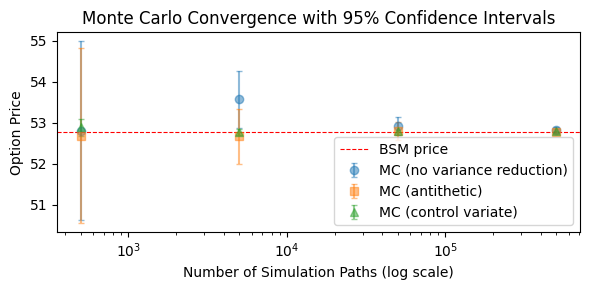

In [2]:
# parameters
seed = None

s = 100
k = 50
r = 0.1
sigma = 0.25
T = 1
q = 0.02

option_type = 'call'
exercise_style = 'European'

N_paths = np.asarray([500, 5000, 50000, 500000])

price1, price2, price3 = np.zeros(len(N_paths)), np.zeros(len(N_paths)), np.zeros(len(N_paths))
std1, std2, std3 = np.zeros(len(N_paths)), np.zeros(len(N_paths)), np.zeros(len(N_paths))

for i, n_paths in enumerate(N_paths):
    # no variance reduction
    price1[i], std1[i] = price_option_mc(option_type, exercise_style, s, k, r, sigma, T, q, n_paths, 
                          antithetic=False, control_variate=False, seed=seed)
    # antithetic variates
    price2[i], std2[i] = price_option_mc(option_type, exercise_style, s, k, r, sigma, T, q, n_paths, 
                          antithetic=True, control_variate=False, seed=seed)
    # control variate
    price3[i], std3[i] = price_option_mc(option_type, exercise_style, s, k, r, sigma, T, q, n_paths, 
                          antithetic=False, control_variate=True, seed=seed)

price_bsm = price_option_bsm(option_type, exercise_style, s, k, r, sigma, T, q)

# 95% confidence level
ci1 = 1.96*std1
ci2 = 1.96*std2
ci3 = 1.96*std3

plt.figure(figsize=(6,3))

plt.errorbar(N_paths, price1, yerr=ci1, fmt='o', capsize=2, alpha=0.5,
             label='MC (no variance reduction)')

plt.errorbar(N_paths, price2, yerr=ci2, fmt='s', capsize=2, alpha=0.5,
             label='MC (antithetic)')

plt.errorbar(N_paths, price3, yerr=ci3, fmt='^', capsize=2, alpha=0.5,
             label='MC (control variate)')

plt.axhline(price_bsm, linestyle='--', color='red', linewidth=0.8,
            label='BSM price')

plt.xscale('log')

plt.xlabel('Number of Simulation Paths (log scale)')
plt.ylabel('Option Price')
plt.title('Monte Carlo Convergence with 95% Confidence Intervals')
plt.legend()

plt.tight_layout()
plt.show()